## Overview

**Data Preparation**:
1. Review key findings
2. Build a Data Quality Plan
3. Implement fixes (drop, correct, clamp, impute)
4. Validate and save clean data



Import Required Libraries and Load Data

In [267]:
# Import required libraries for data quality analysis

import pandas as pd      # For data frame manipulation and CSV reading
import numpy as np       # For numerical computations
import matplotlib.pyplot as plt  # For creating visualizations
import re                # For address extraction

# Display plots inline in the notebook
%matplotlib inline

### Detailed Data Quality Plan

Based on the findings, here is our comprehensive plan for handling each feature:

### A comprehension of data issues


| Feature | Type | Data Quality Issue(s) | Impact | Root Cause Analysis | Proposed Solution | Final Action |
|---------|------|----------------------|--------|-------------------|------------------|--------------|
| **DateofSale(dd/mm/yyyy)** | object | Too much cardinality, not useful for prediction.| High | Natuaral records of dates| Extract year and month  |  Drop the original column and extract year and month from it. |
| **Address** | object | Too much cardinality, not useful for prediction. | High | Natuaral records of different properties | Investigate weather it can be converted to eircode. If not, drop it. | Drop the original column and extract area|
| **County** | category | No issue | Low | No issue | Keep  | Keep  |
| **Eircode** | object | Too much cardinality, not useful for prediction. | High | Natuaral records of different properties | Try to fill it by address and extract the district from eircode. If can't, drop it.  | Drop  |
| **Eircode** | object | Too much missing(68.86%), not useful for prediction.  | High | Data not collected | Try to fill it by address. If can't, drop it.  | Drop  |
| **Price** | float64 | Outliers and extremes | Medium | Most high values are valid outliers but several extremes need more investigation| Clamp the price to upper bound | Log Transformation. Compared to clamping, log transformation maintains the integrity of the data distribution and improves suitability for modeling. |
| **NotFullMarketPrice** | category | No issue | Low | Binary categorical feature | Keep | Keep |
| **VATExclusive** | category | No issue | Low | Binary categorical feature | Keep | Keep |
| **DescriptionofProperty** | category | No issue | Low | Records of property types | Keep | Keep |
| **PropertySizeDescription** | category | Too much missing(97.73%), not useful for prediction. | High | Data not collected | Drop the feature | Drop |
| **Other** | none | 4 duplicate rows | low | recording error | Remove duplicate rows | Remove |

**Summary of Actions:**
- **DROP 3 features**: Eircode(68.86% missing), PropertySizeDescription, Datetime(Extract Year and Month from it)
- **DROP 4 row**: 4 duplicate rows
- **TRANSFORM 1 feature**: Applied log transformation to `Price (€)` by creating a new feature `log_price`
- **Add 2 features**: saleYear, saleMonth
- **EXTRACT 1 feature**: Created `Region` by extracting Dublin district information from Address using regex patterns (e.g., D1, Dublin 2), with default categories for non-Dublin and unmatched cases

## Section 1: Implementation of Data Quality Strategies

In [268]:
# Load the dataset of DQR from CSV file
# Parameters:
#   - keep_default_na=True: Treat standard NaN representations as missing (not as text)
#   - delimiter=',': CSV file uses comma as delimiter  
#   - skipinitialspace=True: Remove leading whitespace after delimiter for cleaner column names
df = pd.read_csv('ppr-group-25204989-train-v1.csv', keep_default_na=True, delimiter=',', skipinitialspace=True)

# Configure pandas display options for better readability
pd.set_option('display.max_rows', 100)  # Show up to 100 rows in output

# Display the first 5 rows to inspect the data structure
df.head(5)

,Date of Sale (dd/mm/yyyy),Address,County,Eircode,Price (€),Not Full Market Price,VAT Exclusive,Description of Property,Property Size Description
0,04/07/2016,"9 AL UISCE, ENNISCORTHY, CO WEXFORD",Wexford,NaN,62500.0,No,No,Second-Hand Dwelling house /Apartment,NaN
1,21/12/2016,"2 BEECHVILLE, THE LOUTH, CORK",Cork,NaN,150000.0,Yes,No,Second-Hand Dwelling house /Apartment,NaN
2,23/08/2016,"75 BELLEFIELD RD, ENNISCORTHY, WEXFORD",Wexford,NaN,94000.0,No,No,Second-Hand Dwelling house /Apartment,NaN
3,23/02/2016,"No. 6, St. Caillins View, Fenagh",Leitrim,NaN,149500.0,No,Yes,New Dwelling house /Apartment,greater than 125 sq metres
4,07/10/2016,"NO7 GRATTAN PARK, CONVENT RD, CLAREMORRIS",Mayo,NaN,170000.0,No,No,Second-Hand Dwelling house /Apartment,NaN


In [269]:
# check data types of each column
print(df.dtypes)

Date of Sale (dd/mm/yyyy)     object
Address                       object
County                        object
Eircode                       object
Price (€)                    float64
Not Full Market Price         object
VAT Exclusive                 object
Description of Property       object
Property Size Description     object
dtype: object


Since CSV files do not preserve pandas dtype information, any type conversions performed during the DQR stage are not retained when the dataset is reloaded.
Therefore, in the DQP stage, we explicitly re-cast the relevant columns (e.g., categorical and date features) to their intended data types before proceeding with further processing.

In [270]:
# Convert all object columns to categorical
for col in df.select_dtypes('object').columns:
    df[col] = df[col].astype('category')

# Change type of "Date of Sale (dd/mm/yyyy)" and "Address" 
df['Address']=df['Address'].astype('object')
df['Date of Sale (dd/mm/yyyy)']=df['Date of Sale (dd/mm/yyyy)'].astype('object')
df['Eircode']=df['Eircode'].astype('object')


numeric_columns = df.select_dtypes(['int64', 'float64']).columns
category_columns = df.select_dtypes('category').columns
object_columns=df.select_dtypes('object').columns

# Summary: Show feature categorization results
print("="*70)
print("FEATURE TYPES CONFIGURED FOR DATA QUALITY ASSESSMENT")
print("="*70)
print(f"\n✓ Numeric features ({len(numeric_columns)}):")
print(f"   {list(numeric_columns)}")
print(f"\n✓ Categorical features ({len(category_columns)}):")
print(f"   {list(category_columns)}")
print(f"\n✓ object features({len(object_columns)})")
print(f"   {list(object_columns)}")
print("\n" + "="*70)

FEATURE TYPES CONFIGURED FOR DATA QUALITY ASSESSMENT

✓ Numeric features (1):
   ['Price (€)']

✓ Categorical features (5):
   ['County', 'Not Full Market Price', 'VAT Exclusive', 'Description of Property', 'Property Size Description']

✓ object features(3)
   ['Date of Sale (dd/mm/yyyy)', 'Address', 'Eircode']



### Step 1: Create a backup of the original data from DQR
This allows us to compare and validate our transformations later

In [271]:
df_raw = df.copy()

print("="*70)
print("BACKUP CREATED")
print("="*70)
print(f"Original dataset preserved with shape: {df_raw.shape}")
print(f"Rows: {df_raw.shape[0]}, Columns: {df_raw.shape[1]}")
print(f"Columns: {list(df_raw.columns)}")
print("="*70)

BACKUP CREATED
Original dataset preserved with shape: (54000, 9)
Rows: 54000, Columns: 9
Columns: ['Date of Sale (dd/mm/yyyy)', 'Address', 'County', 'Eircode', 'Price (€)', 'Not Full Market Price', 'VAT Exclusive', 'Description of Property', 'Property Size Description']


### Step 2: Investigate and Drop Problematic Features

We verify the two problematic features identified in DQR, then drop them in one step.
The code below documents the checks and the final drop operation.

In [272]:
# Step 2a: Verify the problematic features exist and analyse them before dropping
print("Analysis of Features to Drop:")
print("-" * 70)


# Analyze Eircode
print("\n1. Eircode - Missing Data Check:")
zeros_count = (df['Eircode'] == 0).sum()
missing_count = df['Eircode'].isnull().sum()
total_problematic = zeros_count + missing_count
pct_problematic = 100 * total_problematic / len(df)
print(f"   Number of zeros: {zeros_count}")
print(f"   Number of NaN: {missing_count}")
print(f"   Total problematic values: {total_problematic} ({pct_problematic:.1f}%)")
print("   → Decision: TOO MANY MISSING VALUES - DROP")

# Analyze Property Size Description
print("\n2. Property Size Description - Missing Data check:")
missing_count = df['Property Size Description'].isnull().sum()
pct_missing = 100 * missing_count / len(df)
print(f"   Number of missing values: {missing_count} ({pct_missing:.1f}%)")
print(f"   Non-missing value counts:")
print(f"   {df['Property Size Description'].value_counts(dropna=False)}")
print("   → Decision: EXCESSIVE MISSING DATA - DROP")

print("\n" + "="*70)
print("DROPPING FEATURES")
print("="*70)

# Drop the problematic columns
features_to_drop = ['Eircode', 'Property Size Description']
df = df.drop(features_to_drop, axis=1)

print(f"\n✓ Successfully dropped {len(features_to_drop)} features:")
for feat in features_to_drop:
    print(f"  - {feat}")
print(f"\nDataset shape after dropping features: {df.shape}")
print(f"Remaining columns ({df.shape[1]}): {list(df.columns)}")

Analysis of Features to Drop:
----------------------------------------------------------------------

1. Eircode - Missing Data Check:
   Number of zeros: 0
   Number of NaN: 37183
   Total problematic values: 37183 (68.9%)
   → Decision: TOO MANY MISSING VALUES - DROP

2. Property Size Description - Missing Data check:
   Number of missing values: 51152 (94.7%)
   Non-missing value counts:
   Property Size Description
NaN                                                                  51152
greater than or equal to 38 sq metres and less than 125 sq metres     2073
greater than or equal to 125 sq metres                                 537
less than 38 sq metres                                                 133
greater than 125 sq metres                                             105
Name: count, dtype: int64
   → Decision: EXCESSIVE MISSING DATA - DROP

DROPPING FEATURES

✓ Successfully dropped 2 features:
  - Eircode
  - Property Size Description

Dataset shape after dropping feat

### Step 3: Investigate and Remove duplicate rows

From the DQR analysis, we identified that there are duplicate records in the dataset.
Therefore, we investigate the presence of duplicates and remove them if confirmed.

In [273]:
print("="*70)
print("Investigation 1: Investigate Duplicate Rows")
print("="*70)

# Count duplicate rows
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows detected: {duplicate_count}")

if duplicate_count > 0:
    print("\nDuplicate rows found. Displaying duplicate entries:")
    display(df[df.duplicated(keep=False)])
else:
    print("\nNo duplicate rows found.")

Investigation 1: Investigate Duplicate Rows
Number of duplicate rows detected: 4

Duplicate rows found. Displaying duplicate entries:


,Date of Sale (dd/mm/yyyy),Address,County,Price (€),Not Full Market Price,VAT Exclusive,Description of Property
814,27/09/2016,"LISNANAGH, EDGEWORTHSTOWN, LONGFORD",Longford,140000.0,Yes,No,Second-Hand Dwelling house /Apartment
2752,27/09/2016,"LISNANAGH, EDGEWORTHSTOWN, LONGFORD",Longford,140000.0,Yes,No,Second-Hand Dwelling house /Apartment
7404,12/12/2017,"26 27 POPES QUAY, NORTH QUAY PLACE, CORK",Cork,135000.0,No,No,Second-Hand Dwelling house /Apartment
9273,12/12/2017,"26 27 POPES QUAY, NORTH QUAY PLACE, CORK",Cork,135000.0,No,No,Second-Hand Dwelling house /Apartment
21308,07/01/2019,"THE COACH HOUSE, CIRCULAR RD, DUNMORE EAST",Waterford,108333.0,Yes,No,Second-Hand Dwelling house /Apartment
23994,07/01/2019,"THE COACH HOUSE, CIRCULAR RD, DUNMORE EAST",Waterford,108333.0,Yes,No,Second-Hand Dwelling house /Apartment
48514,12/01/2024,"29 KING STREET, BELLTREE, CLONGRIFFIN",Dublin,570000.0,No,No,Second-Hand Dwelling house /Apartment
49945,12/01/2024,"29 KING STREET, BELLTREE, CLONGRIFFIN",Dublin,570000.0,No,No,Second-Hand Dwelling house /Apartment


In [274]:
# Remove duplicates
print("Removing rows with duplicates...")
print(f"Shape before dropping: {df.shape}")

# Get the indices of rows to drop
dup_all_idx = df[df.duplicated(keep=False)].index          
dup_drop_idx = df[df.duplicated()].index                  

print(f"Duplicate groups (all rows) indices: {list(dup_all_idx)}")
print(f"Indices to drop (keeping first occurrence): {list(dup_drop_idx)}")
print(f"Rows to drop: {len(dup_drop_idx)}")
df = df.drop(index=dup_drop_idx)

print(f"Shape after dropping: {df.shape}")
print(f"✓ Successfully removed {len(dup_drop_idx)} duplicate row(s)")

Removing rows with duplicates...
Shape before dropping: (54000, 7)
Duplicate groups (all rows) indices: [814, 2752, 7404, 9273, 21308, 23994, 48514, 49945]
Indices to drop (keeping first occurrence): [2752, 9273, 23994, 49945]
Rows to drop: 4
Shape after dropping: (53996, 7)
✓ Successfully removed 4 duplicate row(s)


### Step 4: Handle Outliers - Log Transformation

To address the strong right-skewness in `Price (€)`, a logarithmic transformation was applied.

A new feature, `log_price`, was created using a natural logarithm transformation (`log1p`). This approach reduces the impact of extreme values while preserving all original observations.

In [275]:
print("="*80)
print("Price Outliers")
print("="*80)

# Get high outliers
q1=df["Price (€)"].quantile(0.25)
q3=df["Price (€)"].quantile(0.75)
upper_bound = q3 + 1.5 * (q3-q1)
lower_bound=q1-1.5 * (q3-q1)
high_outliers_iqr = df[df["Price (€)"] > upper_bound]
low_outliers_iqr = df[df["Price (€)"] < lower_bound]

print(f"Upper bound: {upper_bound:,.2f}")
print(f"Number of high outliers: {len(high_outliers_iqr)}")

if len(high_outliers_iqr) > 0:
    outlier_idx = high_outliers_iqr.index
    print(f"Indices of high outliers: {list(outlier_idx)[:20]}{' ...' if len(outlier_idx) > 20 else ''}")
    display(high_outliers_iqr)
else:
    print("No high outliers detected.")

if len(low_outliers_iqr) > 0:
    outlier_idx = low_outliers_iqr.index
    print(f"Indices of low outliers: {list(outlier_idx)[:20]}{' ...' if len(outlier_idx) > 20 else ''}")
    display(low_outliers_iqr)
else:
    print("No low outliers detected.")

Price Outliers
Upper bound: 675,500.00
Number of high outliers: 3009
Indices of high outliers: [107, 110, 154, 193, 219, 236, 299, 307, 344, 451, 471, 501, 528, 553, 593, 645, 650, 666, 693, 738] ...


,Date of Sale (dd/mm/yyyy),Address,County,Price (€),Not Full Market Price,VAT Exclusive,Description of Property
107,26/07/2016,"Ard Mor, 31 Granville Park, Blackrock",Dublin,991189.0,No,Yes,New Dwelling house /Apartment
110,23/12/2016,"31 GREEN ROAD, BLACKROCK, CO DUBLIN",Dublin,1025000.0,No,No,Second-Hand Dwelling house /Apartment
154,09/11/2016,"29 WOODLANDS PARK, BLACKROCK, DUBLIN",Dublin,2500000.0,No,No,Second-Hand Dwelling house /Apartment
193,25/11/2016,"28 PARKVALE, SANDYFORD ROAD, DUNDRUM",Dublin,740000.0,No,No,Second-Hand Dwelling house /Apartment
219,20/12/2016,"4 FARMLEIGH AVE, BLACKROCK, DUBLIN",Dublin,697500.0,No,No,Second-Hand Dwelling house /Apartment
...,...,...,...,...,...,...,...
53937,30/09/2024,"5 Outfarm Wood Carpenterstown Rd., Castleknock...",Dublin,985436.0,No,Yes,New Dwelling house /Apartment
53941,15/03/2024,"79 BOTANIC RD, GLASNEVIN, DUBLIN 9",Dublin,700000.0,No,No,Second-Hand Dwelling house /Apartment
53969,08/05/2024,"3 KENT TERRACE, BARNHILL RD, DALKEY",Dublin,1450000.0,No,No,Second-Hand Dwelling house /Apartment
53986,16/09/2024,"18 CARRIGLEA, KILLENARD, PORTARLINGTON",Laois,695000.0,No,No,Second-Hand Dwelling house /Apartment


No low outliers detected.


In [276]:
print("\n" + "="*80)
print("Applying Log Transformation to Price (€)")
print("="*80)

shape_before = df.shape

# create a new log-transformed feature
df["log_price"] = np.log1p(df["Price (€)"])

max_after = df["log_price"].max()

print(f"Shape before: {shape_before}")

# Validation
nan_count = df["log_price"].isna().sum()
inf_count = np.isinf(df["log_price"]).sum()

print(f"Validation - NaN values in log_price: {nan_count}")
print(f"Validation - Inf values in log_price: {inf_count}")


Applying Log Transformation to Price (€)
Shape before: (53996, 7)
Validation - NaN values in log_price: 0
Validation - Inf values in log_price: 0


In [277]:
print("="*80)
print("log_price Outliers")
print("="*80)

# Get high outliers
q1=df["log_price"].quantile(0.25)
q3=df["log_price"].quantile(0.75)
upper_bound = q3 + 1.5 * (q3-q1)
lower_bound=q1-1.5 * (q3-q1)
high_outliers_iqr = df[df["log_price"] > upper_bound]
low_outliers_iqr = df[df["log_price"] < lower_bound]

print(f"Upper bound: {upper_bound:,.2f}")
print(f"Number of high outliers: {len(high_outliers_iqr)}")

if len(high_outliers_iqr) > 0:
    outlier_idx = high_outliers_iqr.index
    print(f"Indices of high outliers: {list(outlier_idx)[:20]}{' ...' if len(outlier_idx) > 20 else ''}")
    display(high_outliers_iqr)
else:
    print("No high outliers detected.")

if len(low_outliers_iqr) > 0:
    outlier_idx = low_outliers_iqr.index
    print(f"Indices of low outliers: {list(outlier_idx)[:20]}{' ...' if len(outlier_idx) > 20 else ''}")
    display(low_outliers_iqr)
else:
    print("No low outliers detected.")

log_price Outliers
Upper bound: 14.06
Number of high outliers: 718
Indices of high outliers: [154, 236, 528, 835, 967, 973, 1054, 1550, 1714, 1820, 1905, 2158, 2164, 2189, 2243, 2368, 2427, 2514, 2605, 2673] ...


,Date of Sale (dd/mm/yyyy),Address,County,Price (€),Not Full Market Price,VAT Exclusive,Description of Property,log_price
154,09/11/2016,"29 WOODLANDS PARK, BLACKROCK, DUBLIN",Dublin,2500000.0,No,No,Second-Hand Dwelling house /Apartment,14.731802
236,29/09/2016,"6 WALTHAM TERRACE, BLACKROCK, DUBLIN",Dublin,2275000.0,No,No,Second-Hand Dwelling house /Apartment,14.637491
528,14/06/2016,"2C ARRAN ST EAST, DUBLIN 7",Dublin,2562500.0,No,No,Second-Hand Dwelling house /Apartment,14.756494
835,22/07/2016,"19 GREEN PARK, ORWELL ROAD, RATHGAR",Dublin,2850000.0,No,No,Second-Hand Dwelling house /Apartment,14.862830
967,26/07/2016,"11 GREENFIELD CRESCENT, DONNYBROOK, DUBLIN 4",Dublin,2700000.0,No,No,Second-Hand Dwelling house /Apartment,14.808763
...,...,...,...,...,...,...,...,...
53688,24/05/2024,"35 HERBERT LANE and, 3 Apartments 10 Herbert P...",Dublin,2650000.0,No,No,Second-Hand Dwelling house /Apartment,14.790071
53695,18/12/2024,"THE MOORINGS, HARBOUR ROAD, DALKEY",Dublin,2175000.0,No,No,Second-Hand Dwelling house /Apartment,14.592540
53697,12/02/2024,"OVER YONDER, ARDBRACK, KINSALE",Cork,2900000.0,No,No,Second-Hand Dwelling house /Apartment,14.880222
53821,23/10/2024,"8 MAPLE RD, CLONSKEAGH, DUBLIN 14",Dublin,2737500.0,No,No,Second-Hand Dwelling house /Apartment,14.822556


Indices of low outliers: [7, 20, 27, 33, 55, 71, 87, 98, 101, 129, 143, 161, 180, 185, 205, 217, 233, 253, 254, 297] ...


,Date of Sale (dd/mm/yyyy),Address,County,Price (€),Not Full Market Price,VAT Exclusive,Description of Property,log_price
7,28/10/2016,"10 MILLMOUNT TERRACE, DUNDRUM RD, MILLTOWN DUB...",Dublin,15000.0,No,No,Second-Hand Dwelling house /Apartment,9.615872
20,12/08/2016,"45 WESTSIDE APARTMENTS, LETTERKENNY, CO DONEGAL",Donegal,30500.0,No,No,Second-Hand Dwelling house /Apartment,10.325515
27,06/05/2016,"13 KING STREET, WEXFORD",Wexford,39500.0,No,No,Second-Hand Dwelling house /Apartment,10.584081
33,28/06/2016,"20 FATIMA PARK, DUNDALK, LOUTH",Louth,30000.0,Yes,No,Second-Hand Dwelling house /Apartment,10.308986
55,20/04/2016,"15 SONAS VILLAGE, ENNISCRONE, CO SLIGO",Sligo,35242.0,No,No,Second-Hand Dwelling house /Apartment,10.470022
...,...,...,...,...,...,...,...,...
53621,27/03/2024,"TIRHOMIN, MILFORD, CO. DONEGAL",Donegal,40000.0,No,No,Second-Hand Dwelling house /Apartment,10.596660
53633,30/04/2024,"CLOUGHAL BEG, BELMONT, BIRR",Offaly,40000.0,No,No,Second-Hand Dwelling house /Apartment,10.596660
53842,04/12/2024,"5 JUBILEE TERRACE, ANALORE ST, CLONES",Monaghan,40000.0,No,No,Second-Hand Dwelling house /Apartment,10.596660
53848,10/09/2024,"TULLYNASKEAGH, BAILIEBOROUGH, CO CAVAN",Cavan,17000.0,No,No,Second-Hand Dwelling house /Apartment,9.741027


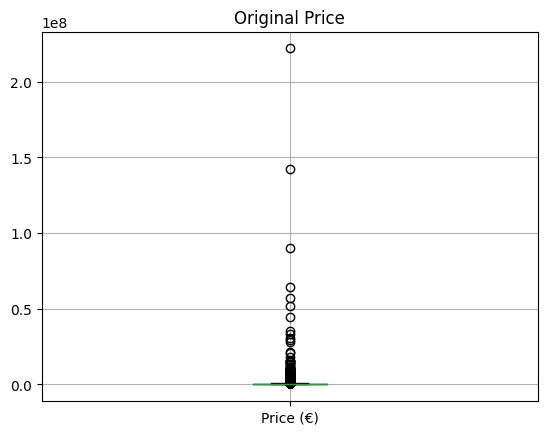

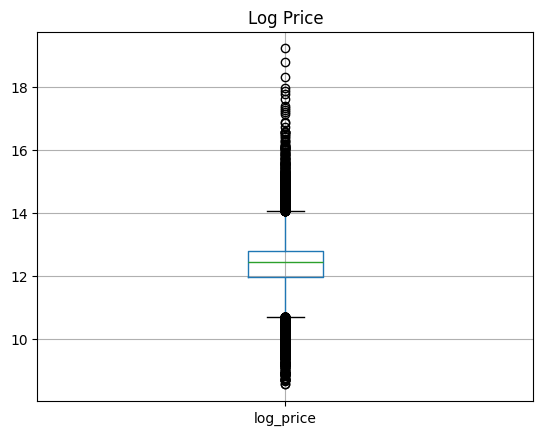

In [278]:
#before log
plt.figure()
df.boxplot(column="Price (€)")
plt.title("Original Price")
plt.show()

# after log
plt.figure()
df.boxplot(column="log_price")
plt.title("Log Price")
plt.show()

<Figure size 640x480 with 0 Axes>

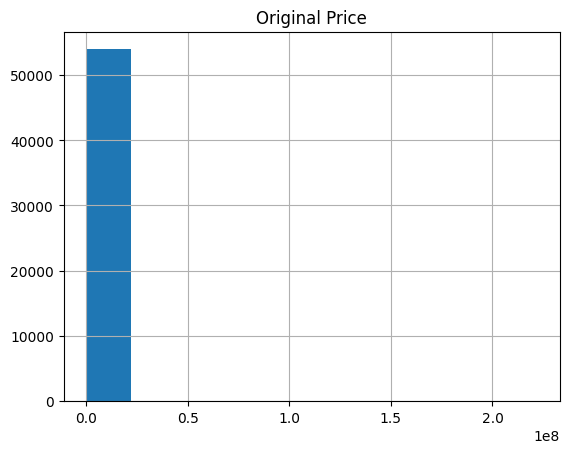

<Figure size 640x480 with 0 Axes>

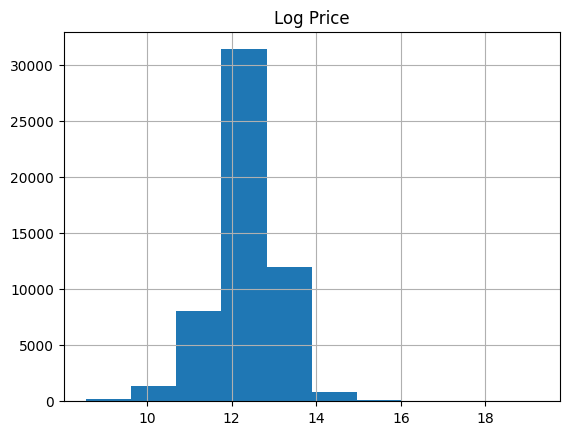

In [279]:
#before log
plt.figure()
df.hist(column="Price (€)")
plt.title("Original Price")
plt.show()

# after log
plt.figure()
df.hist(column="log_price")
plt.title("Log Price")
plt.show()

### Step 5: Feature Engineering


#### 1. Datetime extraction
The original date column exhibits very high cardinality, as each transaction is associated with a unique sale date. 
Such high-cardinality features are not directly useful for predictive modeling and may introduce noise. Therefore, we extract the year and month components to capture meaningful temporal patterns and remove the original date column.

In [280]:
# Convert to datetime (format: dd/mm/yyyy)
df["Date of Sale (dd/mm/yyyy)"] = pd.to_datetime(
    df["Date of Sale (dd/mm/yyyy)"],
    dayfirst=True,
    errors="coerce"
)

print("Date conversion completed.")

# Extract temporal features
df["SaleYear"] = df["Date of Sale (dd/mm/yyyy)"].dt.year
df["SaleMonth"] = df["Date of Sale (dd/mm/yyyy)"].dt.month

print("Year and Month extracted successfully.")

# Convert SaleMonth to categorical for better memory efficiency and analysis
df["SaleMonth"] = df["SaleMonth"].astype("category")


Date conversion completed.
Year and Month extracted successfully.


In [281]:
print("="*70)
print("Verification: Newly Created Temporal Features")
print("="*70)

# Preview new columns
print("\nPreview of SaleYear and SaleMonth:")
display(df[["SaleYear", "SaleMonth"]].head())

# Preview the full dataset to see new features in context
print("\nPreview of full dataset with new features:")
display(df.head(10))

# Check data types of relevant columns
print("\nData types of new features:")
print(df[["SaleYear", "SaleMonth"]].dtypes)

# Check value ranges
print("\nUnique SaleYear values:")
print(df["SaleYear"].unique())

print("\nUnique SaleMonth values:")
print(sorted(df["SaleMonth"].unique()))

Verification: Newly Created Temporal Features

Preview of SaleYear and SaleMonth:


,SaleYear,SaleMonth
0,2016,7
1,2016,12
2,2016,8
3,2016,2
4,2016,10



Preview of full dataset with new features:


,Date of Sale (dd/mm/yyyy),Address,County,Price (€),Not Full Market Price,VAT Exclusive,Description of Property,log_price,SaleYear,SaleMonth
0,2016-07-04,"9 AL UISCE, ENNISCORTHY, CO WEXFORD",Wexford,62500.0,No,No,Second-Hand Dwelling house /Apartment,11.042938,2016,7
1,2016-12-21,"2 BEECHVILLE, THE LOUTH, CORK",Cork,150000.0,Yes,No,Second-Hand Dwelling house /Apartment,11.918397,2016,12
2,2016-08-23,"75 BELLEFIELD RD, ENNISCORTHY, WEXFORD",Wexford,94000.0,No,No,Second-Hand Dwelling house /Apartment,11.451061,2016,8
3,2016-02-23,"No. 6, St. Caillins View, Fenagh",Leitrim,149500.0,No,Yes,New Dwelling house /Apartment,11.915058,2016,2
4,2016-10-07,"NO7 GRATTAN PARK, CONVENT RD, CLAREMORRIS",Mayo,170000.0,No,No,Second-Hand Dwelling house /Apartment,12.043560,2016,10
5,2016-12-16,"MAUMEEN, LETTERMORE, COUNTY GALWAY",Galway,50000.0,No,No,Second-Hand Dwelling house /Apartment,10.819798,2016,12
6,2016-12-02,"60 COLLEGEWOOD MANOR, CLANE, KILDARE",Kildare,160000.0,No,No,Second-Hand Dwelling house /Apartment,11.982935,2016,12
7,2016-10-28,"10 MILLMOUNT TERRACE, DUNDRUM RD, MILLTOWN DUB...",Dublin,15000.0,No,No,Second-Hand Dwelling house /Apartment,9.615872,2016,10
8,2016-08-11,"29 CLODAGH RD, AVONDALE, WATERFORD",Waterford,160000.0,No,No,Second-Hand Dwelling house /Apartment,11.982935,2016,8
9,2016-12-23,"8 The Schoolyard, Castlecomer Road, Kilkenny",Kilkenny,320000.0,No,Yes,New Dwelling house /Apartment,12.676079,2016,12



Data types of new features:
SaleYear        int32
SaleMonth    category
dtype: object

Unique SaleYear values:
[2016 2017 2018 2019 2020 2021 2022 2023 2024]

Unique SaleMonth values:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [282]:
# Drop the original date column as it's no longer needed
df.drop(columns=["Date of Sale (dd/mm/yyyy)"], inplace=True)
print("Original date column removed.")

Original date column removed.


#### 2. Address extraction
The original date column exhibits very high cardinality, as each transaction is associated with a specific adderss. 
Such high-cardinality features are not directly useful for predictive modeling and may introduce noise. Therefore, we extract region words to capature useful information.

In [283]:

# set the default value as NON_DUBLIN
df['Region'] = 'NON_DUBLIN'

# define the pattern for matching "Dublin ##""D##" and "Dublin"
pattern = r'\b(DUBLIN\s*\d+|D\d+[A-Z]?|DUBLIN)\b'

# select the rows whose county is Dublin and extract districts from addresses
is_dublin_county = df['County'].str.contains('Dublin', case=False, na=False)
extracted = df.loc[is_dublin_county, 'Address'].astype(str).str.extract(pattern, flags=re.IGNORECASE, expand=True)[0]
extracted = extracted.str.upper().str.replace(' ', '', regex=False)
extracted = extracted.replace('DUBLIN', 'DUBLIN_OTHER')
df['Region'] = extracted

# if no result but the county is dublin, fill it as DUBLIN_OTHER
df.loc[(df['Region'].isna()) & (df['County'].str.contains('Dublin', case=False, na=False)), 'Region'] = 'DUBLIN_OTHER'

df.loc[is_dublin_county, 'Region'] = extracted

df.loc[is_dublin_county & df['Region'].isna(), 'Region'] = 'DUBLIN_OTHER'

df['Region'] = df['Region'].fillna('NON_DUBLIN')

print(df['Region'].value_counts())


Region
NON_DUBLIN      37318
DUBLIN_OTHER     8051
DUBLIN15          973
DUBLIN8           602
DUBLIN7           556
DUBLIN12          524
DUBLIN4           514
DUBLIN24          513
DUBLIN9           509
DUBLIN18          486
DUBLIN11          435
DUBLIN3           432
DUBLIN16          415
DUBLIN14          410
DUBLIN6           402
DUBLIN5           367
DUBLIN13          336
DUBLIN1           325
DUBLIN22          296
DUBLIN2           208
DUBLIN10          145
DUBLIN20           94
DUBLIN17           81
DUBLIN07            1
D7                  1
D1                  1
DUBLIN19            1
Name: count, dtype: int64


In [284]:
df['Region']=df['Region'].replace('D7','DUBLIN7')
df['Region']=df['Region'].replace('DUBLIN07','DUBLIN7')
df['Region']=df['Region'].replace('D1','DUBLIN1')

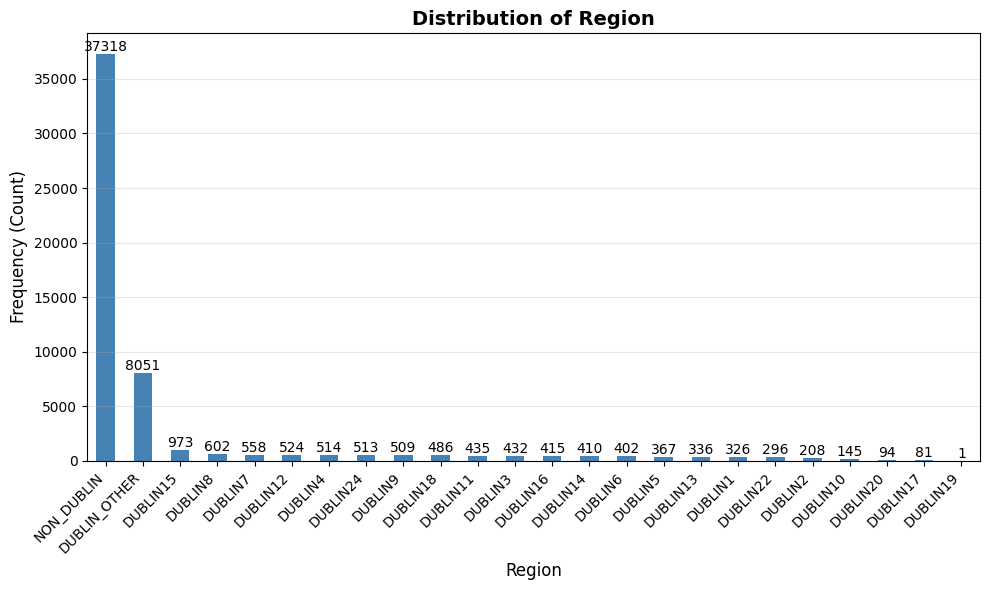

In [285]:
df['Region']=df['Region'].astype('category')

plt.figure(figsize=(10, 6))
ax = df['Region'].value_counts(dropna=False).plot(kind='bar', color='steelblue')
plt.title('Distribution of Region', fontsize=14, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Frequency (Count)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

In [286]:
# Drop the original date column as it's no longer needed
df.drop(columns=["Address"], inplace=True)
print("Original date column removed.")

Original date column removed.


In [287]:
# Standarlize feature names
df.columns = df.columns.str.replace(' ', '')


## Section 2: Validation & Summary

### Step 5: Validate Cleaned Dataset

After implementing all data quality strategies, we validate that:
1. All identified issues have been resolved
2. No new issues were introduced during cleaning
3. Data types are correct
4. No remaining missing values (except where appropriate)
5. Dataset is ready for modeling

In [288]:
print("="*70)
print("DATA QUALITY VALIDATION - FINAL CHECKS")
print("="*70)

# Comparison: Before vs After
print("\n1. DATASET DIMENSIONS COMPARISON")
print("-" * 70)
print(f"Original dataset:")
print(f"  Rows: {df_raw.shape[0]}, Columns: {df_raw.shape[1]}")
print(f"\nCleaned dataset:")
print(f"  Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"\nChanges:")
print(f"  Rows removed: {df_raw.shape[0] - df.shape[0]} (4 duplictate rows)")
print(f"  Columns dropped: {df_raw.shape[1] - df.shape[1]} (2 problematic features)")

# Check for missing values
print("\n2. MISSING VALUES CHECK")
print("-" * 70)
missing_summary = df.isnull().sum()
if missing_summary.sum() == 0:
    print("✓ All missing values processed successfully - NONE remaining")
else:
    print("⚠ WARNING: Remaining missing values found:")
    print(missing_summary[missing_summary > 0])

# Check data types
print("\n3. DATA TYPES CHECK")
print("-" * 70)
print("Remaining features and their types:")
df.info()


# Check for duplicates
print("\n4. DUPLICATE CHECK")
print("-" * 70)
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")
if dup_count == 0:
    print("✓ No duplicate rows found")
else:
    print(f"⚠ WARNING: {dup_count} duplicate rows detected")

print("\n" + "="*70)
print("VALIDATION COMPLETE")
print("="*70)

DATA QUALITY VALIDATION - FINAL CHECKS

1. DATASET DIMENSIONS COMPARISON
----------------------------------------------------------------------
Original dataset:
  Rows: 54000, Columns: 9

Cleaned dataset:
  Rows: 53996, Columns: 9

Changes:
  Rows removed: 4 (4 duplictate rows)
  Columns dropped: 0 (2 problematic features)

2. MISSING VALUES CHECK
----------------------------------------------------------------------
✓ All missing values processed successfully - NONE remaining

3. DATA TYPES CHECK
----------------------------------------------------------------------
Remaining features and their types:
<class 'pandas.core.frame.DataFrame'>
Index: 53996 entries, 0 to 53999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   County                 53996 non-null  category
 1   Price(€)               53996 non-null  float64 
 2   NotFullMarketPrice     53996 non-null  category
 3   VATExclusive    

In [289]:
# Stats for numeric features.
df.describe(include=['int', 'float']).T
print(df.dtypes)

County                   category
Price(€)                  float64
NotFullMarketPrice       category
VATExclusive             category
DescriptionofProperty    category
log_price                 float64
SaleYear                    int32
SaleMonth                category
Region                   category
dtype: object


### Summary: Numeric and Categorical Features After Cleaning

In [290]:
# Stats for category features.
df.describe(include="category").T

,count,unique,top,freq
County,53996,26,Dublin,16678
NotFullMarketPrice,53996,2,No,51170
VATExclusive,53996,2,No,44295
DescriptionofProperty,53996,3,Second-Hand Dwelling house /Apartment,44139
SaleMonth,53996,12,12,6347
Region,53996,24,NON_DUBLIN,37318


In [291]:
df.nunique()

County                     26
Price(€)                 6871
NotFullMarketPrice          2
VATExclusive                2
DescriptionofProperty       3
log_price                6871
SaleYear                    9
SaleMonth                  12
Region                     24
dtype: int64

In [292]:
df.isnull().sum()

County                   0
Price(€)                 0
NotFullMarketPrice       0
VATExclusive             0
DescriptionofProperty    0
log_price                0
SaleYear                 0
SaleMonth                0
Region                   0
dtype: int64

All features seem ok now, no missing values or strange values.

### Step 6: Save Cleaned Dataset
Save the new data frame to a file with a name that reflects that the data has been cleaned.

In [293]:
print("="*70)
print("SAVING CLEANED DATASET")
print("="*70)

# Define output filename with version indicator
output_filename = 'ppr-group-25204989-train-Cleaned.csv'

# Write the cleaned dataframe to a csv file with UTF-8 encoding
df.to_csv(output_filename, index=False, encoding='utf-8')

print(f"\n✓ Cleaned dataset saved successfully")
print(f"\nFile Information:")
print(f"  Filename: {output_filename}")
print(f"  Location: Current working directory")
print(f"  Format: CSV (UTF-8 encoding)")
print(f"  Rows: {df.shape[0]}")
print(f"  Columns: {df.shape[1]}")
print(f"\nDataset is now ready for:")
print(f"  - Data Exploration (relationships between features)")
print(f"  - Feature Engineering (creating derived features)")
print(f"  - Modeling (building predictive models)")
print("="*70)

SAVING CLEANED DATASET

✓ Cleaned dataset saved successfully

File Information:
  Filename: ppr-group-25204989-train-Cleaned.csv
  Location: Current working directory
  Format: CSV (UTF-8 encoding)
  Rows: 53996
  Columns: 9

Dataset is now ready for:
  - Data Exploration (relationships between features)
  - Feature Engineering (creating derived features)
  - Modeling (building predictive models)
